In [1]:
import geopandas as gpd
import pandas as pd
import ee
import os
import geemap
import json
from sqlalchemy import create_engine
from dotenv import load_dotenv
from shapely.geometry import shape

load_dotenv(dotenv_path="./.env")

ee.Initialize()

DB_PASSWORD = os.environ.get('DB_PASSWORD')
DB_IP = os.environ.get('DB_IP')
engine = create_engine(f"mysql+mysqlconnector://root:{DB_PASSWORD}@{DB_IP}:3306/mai-database")

# Import
model_path = "/Users/pauldingus/Documents/MAI/mai_cnn/models/ConvNeXt_transfer/20250520_1230"
country_name = 'Nigeria'
predictions = pd.read_csv(f'{model_path}/all_predictions_{country_name}.csv')
predictions = gpd.GeoDataFrame(predictions, geometry=gpd.GeoSeries.from_wkt(predictions['geometry'])).set_crs("EPSG:4326")
image_metadata = pd.read_csv('data/training_data_S2/image_metadata.csv')
candidate_locs_folder = 'projects/nigeria-candidate-locs/assets'
diffImg = ee.ImageCollection(f'{candidate_locs_folder}/diffImgAll_norm5k')

/Users/pauldingus/Documents/MAI/mai_cnn/.venv/lib/python3.8/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
nigeria_locs = pd.read_sql('SELECT Location, marketDays, lat, lon FROM location_file WHERE country = "Nigeria"', con=engine)
nigeria_locs.head()

,Location,marketDays,lat,lon
0,lon10_0111lat11_4078,{1},11.4078,10.0111
1,lon10_0162lat11_406,None,11.4060,10.0162
2,lon10_0852lat10_5294,{3},10.5294,10.0852
3,lon10_1015lat11_5222,None,11.5222,10.1015
4,lon10_1939lat11_3934,{5},11.3934,10.1939


In [3]:
# Merge image metadata with nigeria locations
image_metadata['Location'] = image_metadata['image_file_path'].apply(lambda x: x.split('/')[2][0:-6])
nigeria_locs = nigeria_locs.merge(image_metadata, on='Location', how='left')

# Convert nigeria_locs to GeoDataFrame using lat and lon
nigeria_locs['geometry'] = nigeria_locs.apply(lambda row: shape({'type': 'Point', 'coordinates': (row['lon'], row['lat'])}), axis=1)
nigeria_locs.head()

,Location,marketDays,lat,lon,image_file_path,market_days,market,min_value,max_value,std_dev,country,geometry
0,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_0...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-1.512247,0.791821,0.149689,Nigeria,POINT (10.0111 11.4078)
1,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_1...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-2.655190,2.250101,0.180264,Nigeria,POINT (10.0111 11.4078)
2,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_0.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-1.116027,2.173678,0.150552,Nigeria,POINT (10.0162 11.406)
3,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_1.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-2.655190,2.250101,0.166189,Nigeria,POINT (10.0162 11.406)
4,lon10_0852lat10_5294,{3},10.5294,10.0852,training_data_S2/images/lon10_0852lat10_5294_0...,"[0, 0, 0, 1, 0, 0, 0]",1.0,-1.263151,1.309403,0.131413,Nigeria,POINT (10.0852 10.5294)


In [4]:
# Get predictions for each location

def get_max_prediction_overlap(geom):
    overlapping = predictions[predictions.geometry.intersects(geom)]
    if not overlapping.empty:
        return overlapping['prediction'].max()
    else:
        return 0

def get_mean_prediction_overlap(geom):
    centroid = geom.centroid
    overlapping = predictions[predictions.geometry.intersects(centroid)]
    pred_values = list(overlapping['prediction'].values)
    if len(pred_values) > 1:
        return sum(pred_values) / len(pred_values)
    elif len(pred_values) == 1:
        return sum(pred_values) / 2
    else:
        return 0
    
nigeria_locs['max_prediction'] = nigeria_locs['geometry'].apply(get_max_prediction_overlap)
nigeria_locs['mean_prediction'] = nigeria_locs['geometry'].apply(get_mean_prediction_overlap)
nigeria_locs.head()

,Location,marketDays,lat,lon,image_file_path,market_days,market,min_value,max_value,std_dev,country,geometry,max_prediction,mean_prediction
0,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_0...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-1.512247,0.791821,0.149689,Nigeria,POINT (10.0111 11.4078),0.966303,0.810328
1,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_1...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-2.655190,2.250101,0.180264,Nigeria,POINT (10.0111 11.4078),0.966303,0.810328
2,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_0.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-1.116027,2.173678,0.150552,Nigeria,POINT (10.0162 11.406),0.889794,0.772074
3,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_1.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-2.655190,2.250101,0.166189,Nigeria,POINT (10.0162 11.406),0.889794,0.772074
4,lon10_0852lat10_5294,{3},10.5294,10.0852,training_data_S2/images/lon10_0852lat10_5294_0...,"[0, 0, 0, 1, 0, 0, 0]",1.0,-1.263151,1.309403,0.131413,Nigeria,POINT (10.0852 10.5294),0.875014,0.744555


## Look for patterns in the data

<Axes: title={'center': 'std_dev vs Mean Prediction'}, xlabel='std_dev', ylabel='Mean Prediction'>

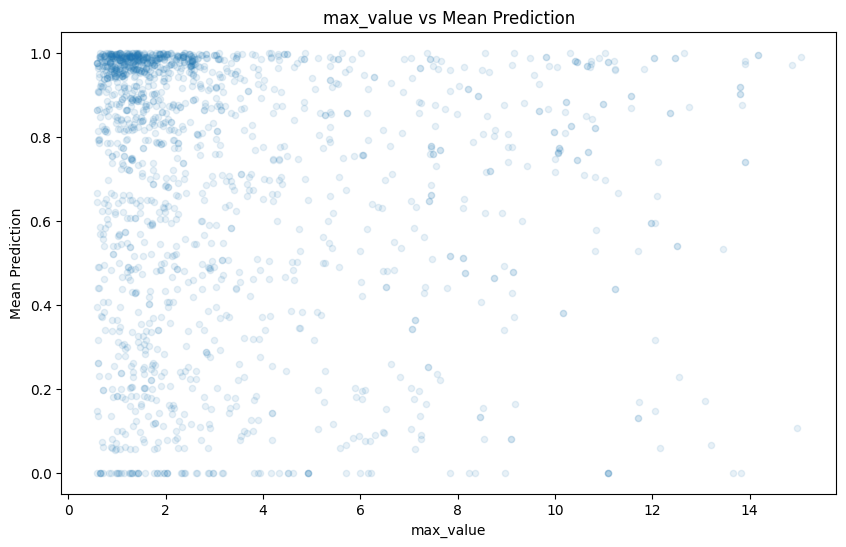

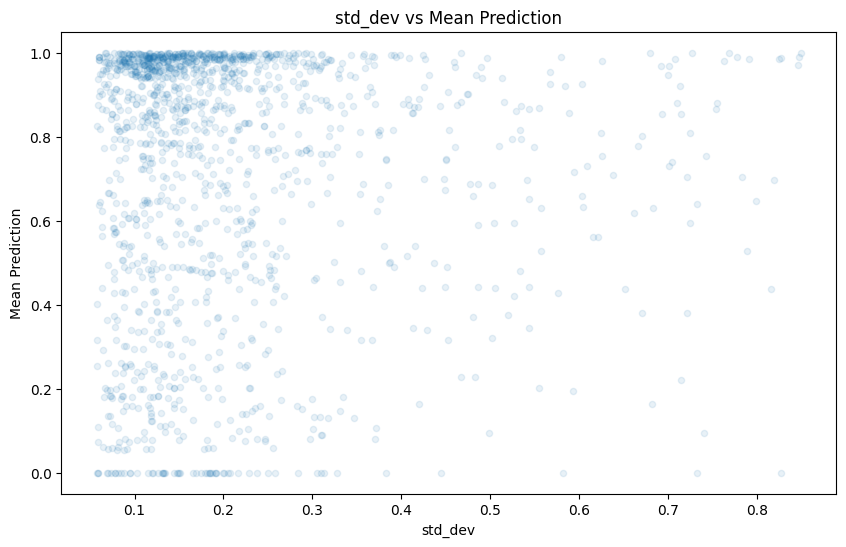

In [6]:
# Plot min_value, max_value, and std_dev vs mean_prediction
# Eliminate outliers based on min_value, max_value, and std_dev before plotting
def plot_vs_mean_prediction(df, column):
    df = df.dropna(subset=[column, 'mean_prediction'])
    df_filtered = df[(df[column] < df[column].quantile(0.95)) & (df[column] > df[column].quantile(0.05))]
    ax = df_filtered.plot.scatter(y='mean_prediction', x=column, title=f'{column} vs Mean Prediction', alpha=0.1, figsize=(10, 6))
    ax.set_ylabel('Mean Prediction')
    ax.set_xlabel(column)
    return ax

plot_vs_mean_prediction(nigeria_locs, 'max_value')
plot_vs_mean_prediction(nigeria_locs, 'std_dev')


In [7]:
nigeria_locs.head()

,Location,marketDays,lat,lon,image_file_path,market_days,market,min_value,max_value,std_dev,country,geometry,max_prediction,mean_prediction
0,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_0...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-1.512247,0.791821,0.149689,Nigeria,POINT (10.0111 11.4078),0.966303,0.810328
1,lon10_0111lat11_4078,{1},11.4078,10.0111,training_data_S2/images/lon10_0111lat11_4078_1...,"[0, 1, 0, 0, 0, 0, 0]",1.0,-2.655190,2.250101,0.180264,Nigeria,POINT (10.0111 11.4078),0.966303,0.810328
2,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_0.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-1.116027,2.173678,0.150552,Nigeria,POINT (10.0162 11.406),0.889794,0.772074
3,lon10_0162lat11_406,None,11.4060,10.0162,training_data_S2/images/lon10_0162lat11_406_1.tif,"[0, 0, 0, 0, 0, 0, 0]",0.0,-2.655190,2.250101,0.166189,Nigeria,POINT (10.0162 11.406),0.889794,0.772074
4,lon10_0852lat10_5294,{3},10.5294,10.0852,training_data_S2/images/lon10_0852lat10_5294_0...,"[0, 0, 0, 1, 0, 0, 0]",1.0,-1.263151,1.309403,0.131413,Nigeria,POINT (10.0852 10.5294),0.875014,0.744555


In [5]:
# Convert nigeria_locs to GeoDataFrame and explore
nigeria_locs = gpd.GeoDataFrame(nigeria_locs, geometry='geometry', crs="EPSG:4326")
nigeria_locs['min_value_clipped'] = nigeria_locs['min_value'].clip(-10, 0)
nigeria_locs.drop(columns = ['marketDays']) \
.explore(
    cmap='viridis', 
    column='min_value_clipped', 
    tooltip=['Location', 'mean_prediction', 'max_value', 'std_dev'], 
    legend=True, 
    marker_kwds={'radius': 5}, 
    name='Nigeria Locations',
    vmax=1
)

## Testing Solutions

In [6]:
import numpy as np
import pandas as pd
import rasterio
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

# --- Insert your own function here ---
def replace_invalid_and_crop(arr: np.ndarray, target_size: int = 128) -> np.ndarray:
    """
    1) Replace inf/nan with 0
    2) Crop to (7, target_size, target_size) if arr shape is larger
    """
    arr[~np.isfinite(arr)] = 0.0

    _, H, W = arr.shape
    if H > target_size:
        arr = arr[:, :target_size, :]
    if W > target_size:
        arr = arr[:, :, :target_size]

    return arr

# Preprocessing function
def preprocess_for_scaling(arr, lower_clip=0, upper_clip=40):
    arr = replace_invalid_and_crop(arr, 128)
    arr = np.clip(arr, lower_clip, upper_clip)
    return arr

def array_stats(arr):
    arr = arr.flatten()
    return {
        'mean': float(np.mean(arr)),
        'std': float(np.std(arr)),
        'min': float(np.min(arr)),
        'max': float(np.max(arr)),
        'median': float(np.median(arr))
    }

# STEP 1: FIT GLOBAL SCALERS

def get_flat_pixels(image_file_paths):
    pixels_list = []
    for path in image_file_paths:
        try:
            with rasterio.open(path) as src:
                arr = src.read()
            arr = preprocess_for_scaling(arr)
            flat = arr.reshape(arr.shape[0], -1).T  # (N, bands=7)
            pixels_list.append(flat)
        except Exception as e:
            print(f"Error reading {path}: {e}")
    return np.vstack(pixels_list)  # (total_pixels, 7)

print("Fitting global scalers...")
image_paths = nigeria_locs['image_file_path'].dropna().tolist()
image_paths = [f'data/{path}' for path in image_paths]
# Select a random sample of 100 image paths
np.random.seed(42)
if len(image_paths) > 100:
    image_paths = np.random.choice(image_paths, 100, replace=False)
global_pixels = get_flat_pixels(image_paths)

global_minmax_scaler = MinMaxScaler().fit(global_pixels)
global_robust_scaler = RobustScaler().fit(global_pixels)
global_std_scaler = StandardScaler().fit(global_pixels)

print("Done fitting global scalers.")

Fitting global scalers...
Done fitting global scalers.


In [8]:

# STEP 2: PROCESS EACH IMAGE

def process_row_with_global_and_perimage_scalers(image_file_path):
    try:
        print(image_file_path)
        image_file_path = f'data/{image_file_path}'
        with rasterio.open(image_file_path) as src:
            img = src.read()
        arr = preprocess_for_scaling(img)
        flat = arr.reshape(arr.shape[0], -1).T

        # Fit per-image scalers
        perimage_minmax = MinMaxScaler().fit(flat)
        perimage_robust = RobustScaler().fit(flat)
        perimage_std = StandardScaler().fit(flat)

        # --- Standardization ---
        arr_std_global = flat.copy()
        arr_std_global = global_std_scaler.transform(arr_std_global)
        arr_std_global = arr_std_global.T.reshape(arr.shape)
        std_global_stats = array_stats(arr_std_global)

        arr_std_local = flat.copy()
        arr_std_local = perimage_std.transform(arr_std_local)
        arr_std_local = arr_std_local.T.reshape(arr.shape)
        std_local_stats = array_stats(arr_std_local)

        # --- Robust ---
        arr_robust_global = flat.copy()
        arr_robust_global = global_robust_scaler.transform(arr_robust_global)
        arr_robust_global = arr_robust_global.T.reshape(arr.shape)
        robust_global_stats = array_stats(arr_robust_global)

        arr_robust_local = flat.copy()
        arr_robust_local = perimage_robust.transform(arr_robust_local)
        arr_robust_local = arr_robust_local.T.reshape(arr.shape)
        robust_local_stats = array_stats(arr_robust_local)

        # --- MinMax ---
        arr_mm_global = flat.copy()
        arr_mm_global = global_minmax_scaler.transform(arr_mm_global)
        arr_mm_global = arr_mm_global.T.reshape(arr.shape)
        mm_global_stats = array_stats(arr_mm_global)

        arr_mm_local = flat.copy()
        arr_mm_local = perimage_minmax.transform(arr_mm_local)
        arr_mm_local = arr_mm_local.T.reshape(arr.shape)
        mm_local_stats = array_stats(arr_mm_local)

        # Collate all
        out = {}
        for prefix, stats in [
            ('std_global', std_global_stats),
            ('std_local', std_local_stats),
            ('robust_global', robust_global_stats),
            ('robust_local', robust_local_stats),
            ('mm_global', mm_global_stats),
            ('mm_local', mm_local_stats),
        ]:
            for k, v in stats.items():
                out[f'{prefix}_{k}'] = v

        return out
    except Exception as e:
        print(f"Error processing {image_file_path}: {e}")
        # Return NaNs for all expected output keys
        keys = [
            'std_global', 'std_local', 'robust_global', 'robust_local', 'mm_global', 'mm_local'
        ]
        stats_keys = ['mean', 'std', 'min', 'max', 'median']
        return {f"{prefix}_{k}": np.nan for prefix in keys for k in stats_keys}

print("Processing images (may take a while)...")
results = nigeria_locs['image_file_path'].apply(process_row_with_global_and_perimage_scalers)
results_df = pd.DataFrame(list(results))

# Save to CSV
results_df.to_csv(f'{model_path}/nigeria_normalization_stats.csv', index=False)
nigeria_locs = pd.concat([nigeria_locs.reset_index(drop=True), results_df], axis=1)

print("Done. Columns now include summary stats for all normalization modes.")


Processing images (may take a while)...
training_data_S2/images/lon10_0111lat11_4078_0.tif
training_data_S2/images/lon10_0111lat11_4078_1.tif
training_data_S2/images/lon10_0162lat11_406_0.tif
training_data_S2/images/lon10_0162lat11_406_1.tif
training_data_S2/images/lon10_0852lat10_5294_0.tif
training_data_S2/images/lon10_0852lat10_5294_1.tif
training_data_S2/images/lon10_1015lat11_5222_0.tif
training_data_S2/images/lon10_1015lat11_5222_1.tif
training_data_S2/images/lon10_1939lat11_3934_0.tif
training_data_S2/images/lon10_1939lat11_3934_1.tif
training_data_S2/images/lon10_1962lat12_9283_0.tif
training_data_S2/images/lon10_1962lat12_9283_1.tif
training_data_S2/images/lon10_3041lat10_7821_0.tif
training_data_S2/images/lon10_3041lat10_7821_1.tif
training_data_S2/images/lon10_3081lat12_9719_0.tif
training_data_S2/images/lon10_3081lat12_9719_1.tif
training_data_S2/images/lon10_3296lat10_2687_0.tif
training_data_S2/images/lon10_3296lat10_2687_1.tif
training_data_S2/images/lon10_3562lat10_8446

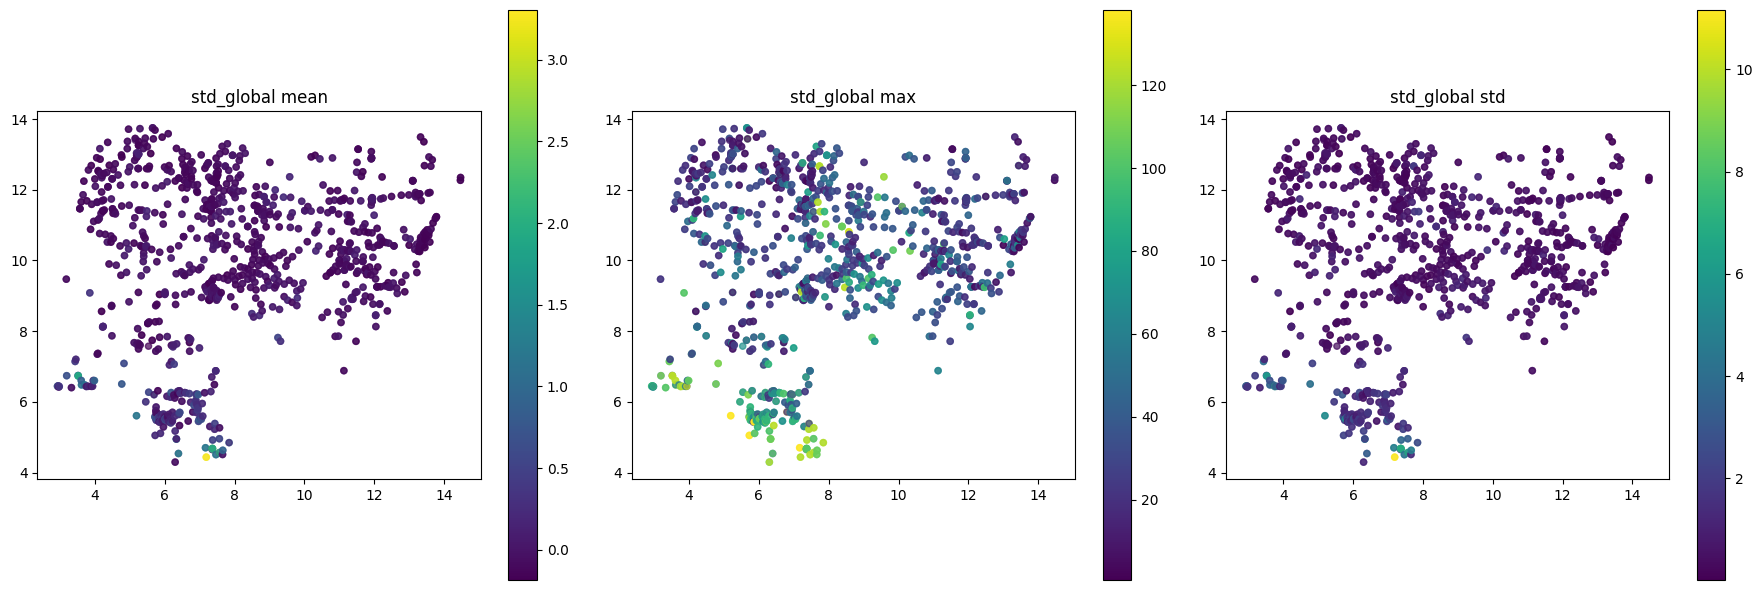

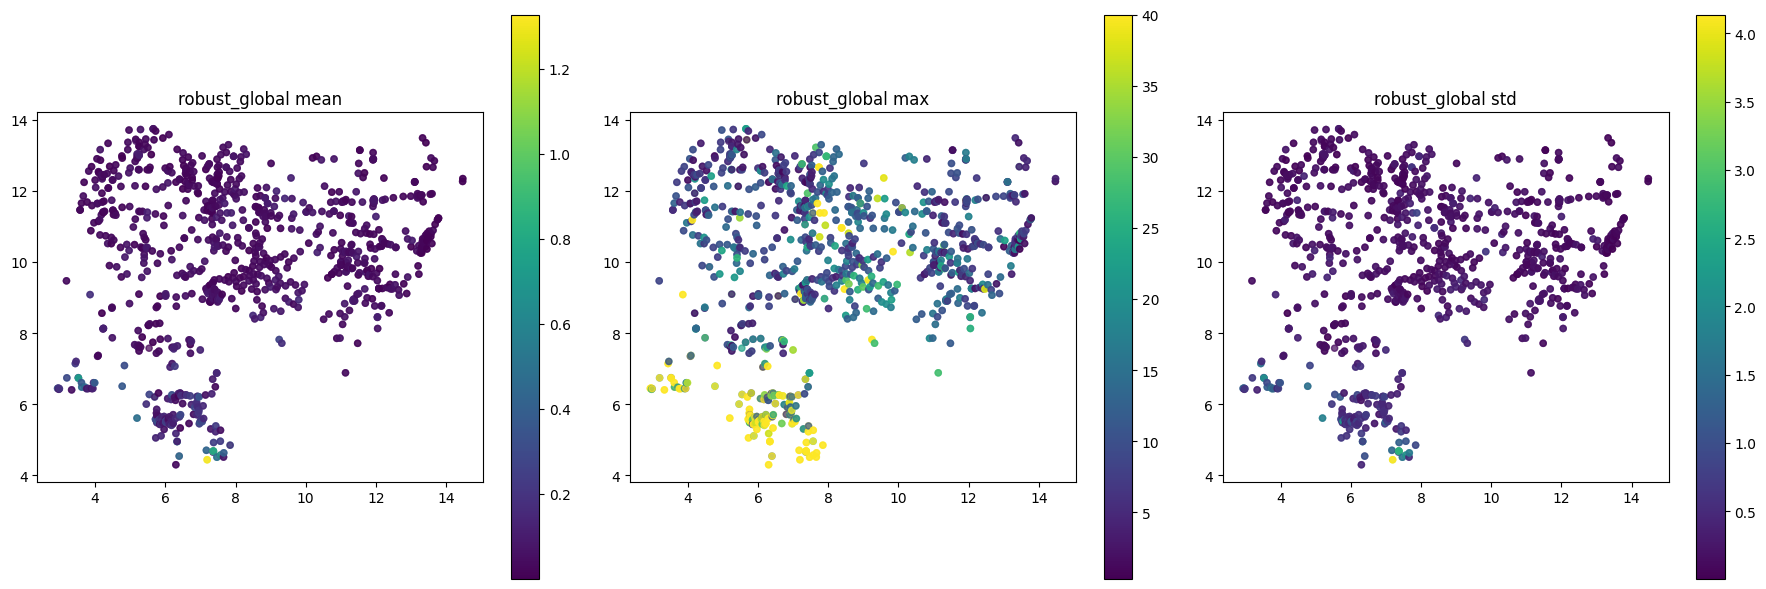

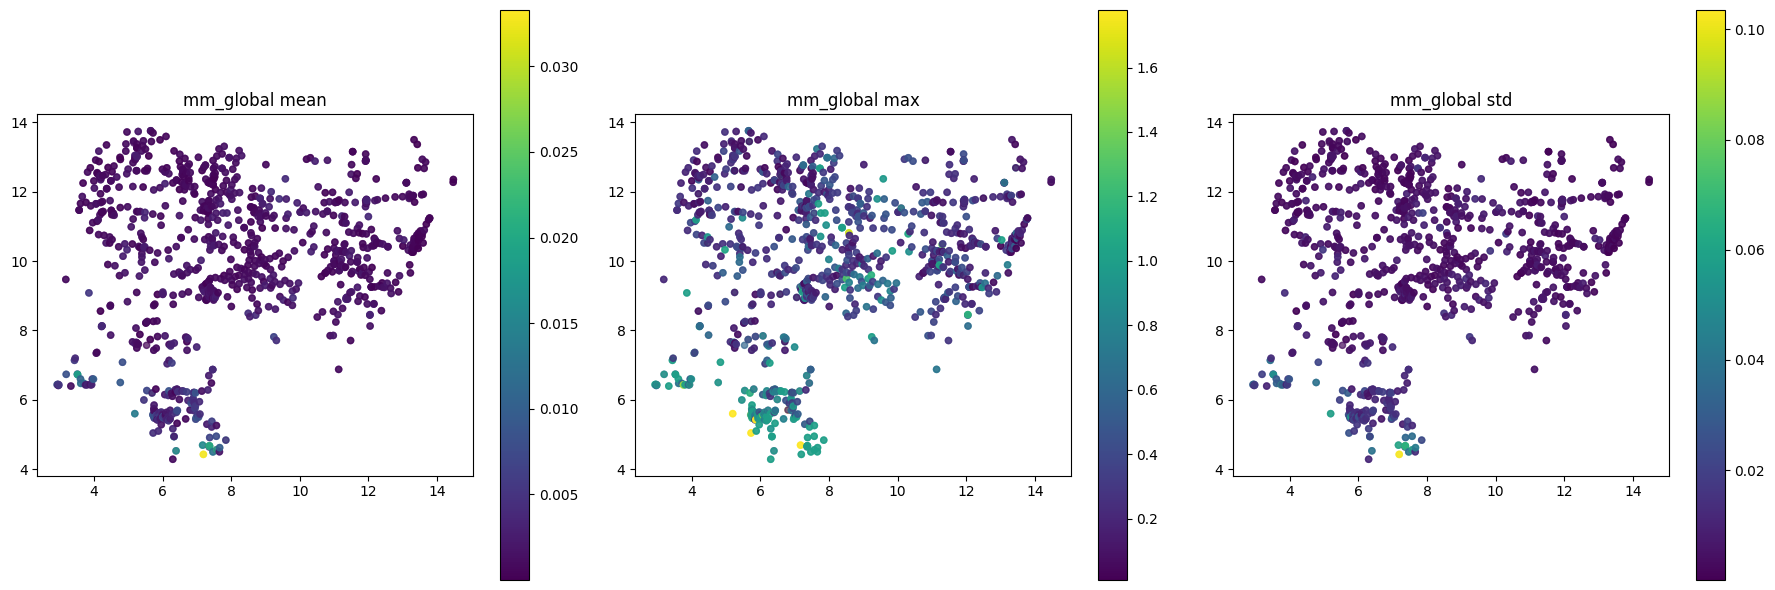

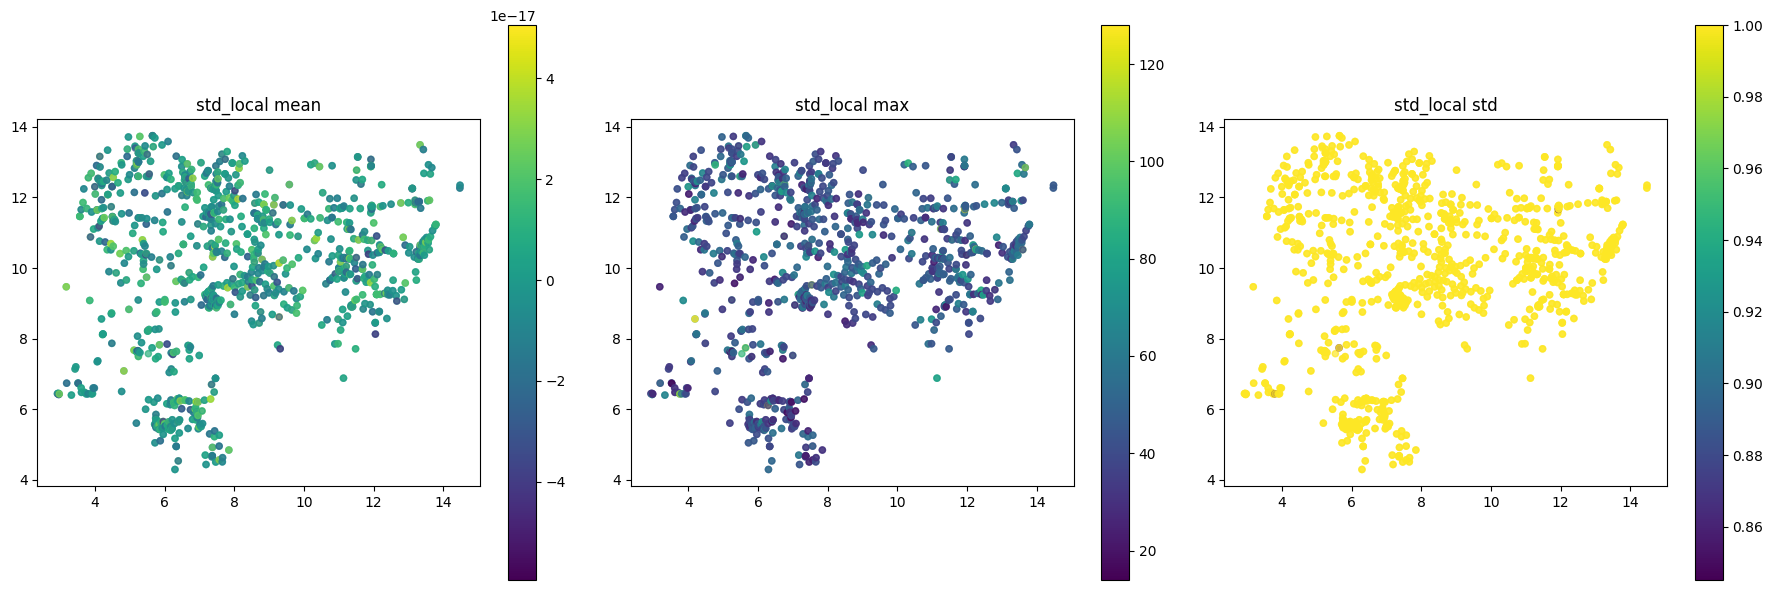

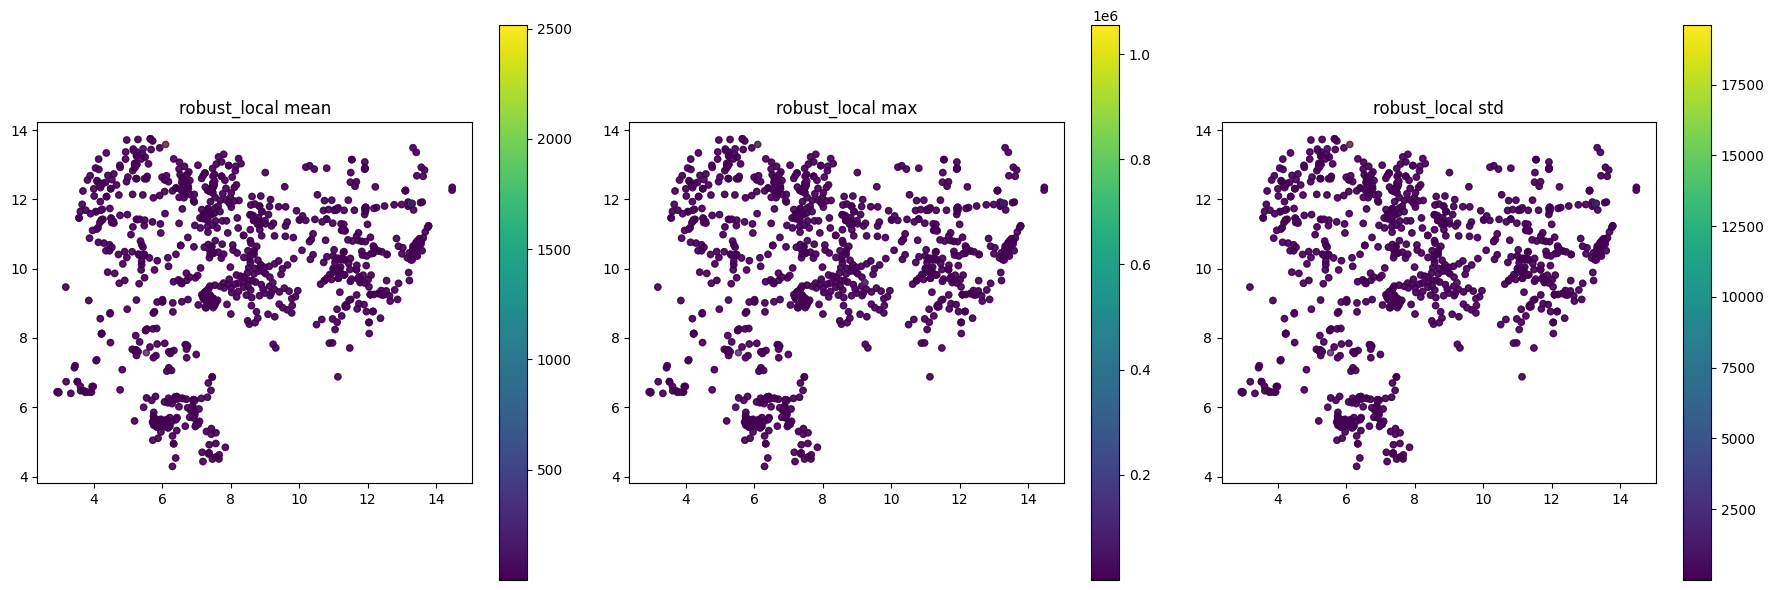

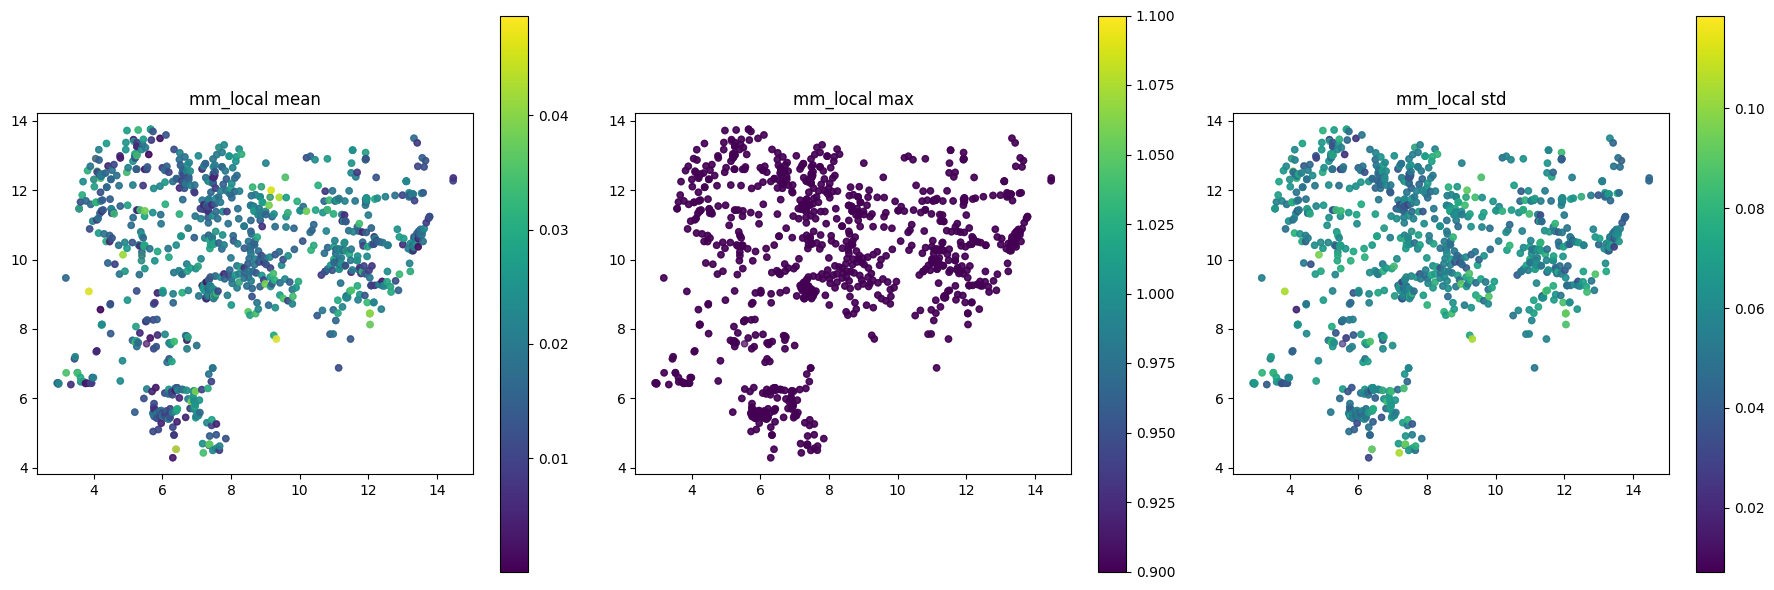

In [13]:
# Map the mean, max, std_dev for one scaler method
def plot_scaler_stats(nigeria_locs, scaler_method):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for i, column in enumerate(['mean', 'max', 'std']):
        ax = axes[i]
        nigeria_locs.plot(
            ax=ax,
            column=f'{scaler_method}_{column}',
            cmap='viridis',
            legend=True,
            markersize=20,
            alpha=0.7
        )
        ax.set_title(f'{scaler_method} {column}')
    plt.tight_layout()
    plt.show()

for scaler in ['std_global', 'robust_global', 'mm_global', 'std_local', 'robust_local', 'mm_local']:
    plot_scaler_stats(nigeria_locs, scaler)